# Job Shop Scheduling Problem (JSSP)
## Formulação Disjuntiva MIP — Resolvido com Gurobi

---

### Artigo de Referência

> **King, B.; Hildebrand, R. (2024).**  
> *Job Shop Scheduling with Integer Programming, Shifting Bottleneck, and Decision Diagrams: A Computational Study.*  
> arXiv:2407.18111 — https://arxiv.org/abs/2407.18111

O artigo realiza um estudo computacional comparando três abordagens para o JSSP:
1. **Programação Inteira (MIP)** com o solver Gurobi — formulação disjuntiva de Manne (1960)
2. **Shifting Bottleneck** — heurística decomposicional clássica
3. **Decision Diagrams** — abordagem baseada em diagramas de decisão

Este notebook reproduz a abordagem **1 (MIP com Gurobi)**.

**Dados (instâncias benchmark públicas):**  
Fisher & Thompson (1963) — disponíveis em: https://github.com/tamy0612/JSPLIB

---

## 1. Descrição do Problema

O **Job Shop Scheduling Problem (JSSP)** é um problema clássico de Otimização Combinatória, classificado como **NP-difícil**. Ele modela situações reais de manufatura e produção.

### Definição Formal

Dado um conjunto de **n jobs** $J = \{0, 1, ..., n-1\}$ e **m máquinas** $M = \{0, 1, ..., m-1\}$:

- Cada job $i$ é composto por uma sequência **fixa e obrigatória** de operações: $O_{i,0} \rightarrow O_{i,1} \rightarrow ... \rightarrow O_{i,|J_i|-1}$
- Cada operação $O_{ij}$ deve ser executada na máquina $m_{ij}$ por um tempo $p_{ij}$ **sem interrupção**
- Cada máquina só pode processar **uma operação por vez**

### Restrições do Problema

| Restrição | Descrição |
|---|---|
| **Precedência** | A operação $j+1$ de um job só pode começar após o término da operação $j$ |
| **Capacidade** | Cada máquina processa no máximo uma operação por vez |
| **Não-preempção** | Uma vez iniciada, uma operação não pode ser interrompida |

### Objetivo

Minimizar o **makespan** $C_{max}$: o instante de término da última operação entre todos os jobs. Ou seja, o tempo total para concluir toda a produção.

### Por que é difícil?

O JSSP é NP-difícil: o número de sequenciamentos possíveis cresce fatorialmente com o tamanho do problema. Para $n$ jobs e $m$ máquinas, há da ordem de $(n!)^m$ soluções possíveis. Para $n=m=6$ (nossa instância), isso equivale a aproximadamente $720^6 \approx 1{,}4 \times 10^{17}$ possibilidades — inviável de enumerar.

---

## 2. Instância Utilizada: FT06

A instância **FT06** foi introduzida por Fisher & Thompson (1963) e é um dos *benchmarks* mais clássicos da literatura de JSSP.

| Parâmetro | Valor |
|---|---|
| Número de jobs ($n$) | **6** |
| Número de máquinas ($m$) | **6** |
| Operações por job | 6 |
| Total de operações | 36 |
| **Makespan ótimo conhecido** | **55** |

Os dados estão disponíveis publicamente em:  
https://github.com/tamy0612/JSPLIB/blob/master/instances/ft06

**Como ler os dados:** cada célula da tabela abaixo representa `(máquina, duração)` de uma operação. O Job 0, por exemplo, começa na Máquina 2 (duração 1), depois vai para a Máquina 0 (duração 3), e assim por diante — **nessa ordem, sem pular etapas**.

| Job | Op.1 | Op.2 | Op.3 | Op.4 | Op.5 | Op.6 |
|---|---|---|---|---|---|---|
| 0 | M2 (1) | M0 (3) | M1 (6) | M3 (7) | M5 (3) | M4 (6) |
| 1 | M1 (8) | M2 (5) | M4(10) | M5(10) | M0(10) | M3 (4) |
| 2 | M2 (5) | M3 (4) | M5 (8) | M0 (9) | M1 (1) | M4 (7) |
| 3 | M1 (5) | M0 (5) | M2 (5) | M3 (3) | M4 (8) | M5 (9) |
| 4 | M2 (9) | M1 (3) | M4 (5) | M5 (4) | M0 (3) | M3 (1) |
| 5 | M1 (3) | M3 (3) | M5 (9) | M0(10) | M4 (4) | M2 (1) |

In [1]:
pip install gurobipy matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


---
## Passo 2 — Carregamento da Instância

### Formato dos arquivos JSPLIB

Os arquivos de instância seguem o formato padrão JSPLIB:
- Linhas começando com `#`, `+` ou `(` são **comentários** e são ignoradas
- A **primeira linha de dados** contém: `n_jobs  n_machines`
- As linhas seguintes contêm **um job por linha**, com pares `máquina  tempo` alternados

**Exemplo de leitura:** a linha `2 1 0 3 1 6 3 7 5 3 4 6` representa o Job 0:  
→ Máquina 2 por 1 unidade, depois Máquina 0 por 3, depois Máquina 1 por 6, e assim por diante.

### Como trocar de instância

Basta alterar o valor de `INSTANCIA` abaixo. As opções disponíveis na pasta `instances/` são:  
`ft06`, `ft10`, `ft20`, `la01` a `la40`, `abz5`, `abz6`, `ta01` a `ta80`, entre outras.

**Observação:** instâncias maiores (como `ft10` com 10×10) podem demorar vários minutos para serem resolvidas de forma exata. O limite de tempo está configurado em 300 segundos.

In [2]:
import os

INSTANCIA = "ft06"

PASTA = os.path.join(os.path.dirname(os.path.abspath("__file__")), "instances")

# Makespan ótimo conhecido para cada instância (literatura)
OTIMOS = {
    "ft06": 55,   "ft10": 930,  "ft20": 1165,
    "la01": 666,  "la02": 655,  "la03": 597,
    "la04": 590,  "la05": 593,  "la06": 926,
    "la07": 890,  "la08": 863,  "la09": 951,
    "la10": 958,  "abz5": 1234, "abz6": 943,
}

# PARSER — lê qualquer arquivo no formato JSPLIB
def carregar_instancia(pasta, nome):
    """
    Lê um arquivo de instância JSSP no formato JSPLIB.

    Parâmetros:
        pasta (str): caminho para a pasta com os arquivos
        nome  (str): nome do arquivo sem extensão

    Retorna:
        jobs_data  (list): lista de jobs; cada job é uma lista de (máquina, tempo)
        n_jobs     (int) : número de jobs
        n_machines (int) : número de máquinas
    """
    caminho = os.path.join(pasta, nome)  

    if not os.path.exists(caminho):
        raise FileNotFoundError(
            f"Arquivo não encontrado: '{caminho}'\n"
            f"Verifique se a pasta 'instances/' está na mesma pasta do notebook."
        )

    jobs_data      = []    # lista que vai acumular os dados de cada job
    n_jobs         = 0
    n_machines     = 0
    cabecalho_lido = False # controla se já lemos a linha n_jobs/n_machines

    with open(caminho, "r") as f:
        for linha in f:
            linha = linha.strip() 

            
            if (not linha
                    or linha.startswith("#")
                    or linha.startswith("+")
                    or linha.startswith("(")):
                continue

            
            numeros = list(map(int, linha.split()))

            # Primeira linha válida: contém n_jobs e n_machines
            if not cabecalho_lido:
                n_jobs, n_machines = numeros[0], numeros[1]
                cabecalho_lido = True
                continue

            # Linhas seguintes: um job por linha
            # Formato: maq0 t0 maq1 t1 maq2 t2 ...
            # Percorre de 2 em 2 para extrair os pares (máquina, tempo)
            if len(numeros) >= 2:
                ops = []
                for k in range(0, len(numeros) - 1, 2):
                    ops.append((numeros[k], numeros[k + 1]))  # (máquina, duração)
                if ops:
                    jobs_data.append(ops)

            # Para quando todos os jobs foram lidos
            if len(jobs_data) == n_jobs:
                break

    return jobs_data, n_jobs, n_machines



jobs_data, n_jobs, n_machines = carregar_instancia(PASTA, INSTANCIA)
OTIMO_CONHECIDO = OTIMOS.get(INSTANCIA, None)

print(f"Instância carregada : {INSTANCIA.upper()}")
print(f"  Jobs              : {n_jobs}")
print(f"  Máquinas          : {n_machines}")
print(f"  Ótimo conhecido   : {OTIMO_CONHECIDO if OTIMO_CONHECIDO else 'não cadastrado'}")
print()
print("Estrutura dos jobs — formato: Máquina(duração)")
print("(leia da esquerda para a direita: essa é a ordem obrigatória das operações)")
print()
for i, job in enumerate(jobs_data):
    ops = " -> ".join(f"M{m}({t})" for m, t in job)
    print(f"  Job {i}: {ops}")

Instância carregada : FT06
  Jobs              : 6
  Máquinas          : 6
  Ótimo conhecido   : 55

Estrutura dos jobs — formato: Máquina(duração)
(leia da esquerda para a direita: essa é a ordem obrigatória das operações)

  Job 0: M2(1) -> M0(3) -> M1(6) -> M3(7) -> M5(3) -> M4(6)
  Job 1: M1(8) -> M2(5) -> M4(10) -> M5(10) -> M0(10) -> M3(4)
  Job 2: M2(5) -> M3(4) -> M5(8) -> M0(9) -> M1(1) -> M4(7)
  Job 3: M1(5) -> M0(5) -> M2(5) -> M3(3) -> M4(8) -> M5(9)
  Job 4: M2(9) -> M1(3) -> M4(5) -> M5(4) -> M0(3) -> M3(1)
  Job 5: M1(3) -> M3(3) -> M5(9) -> M0(10) -> M4(4) -> M2(1)


---
## Passo 3 — Pré-processamento

Antes de construir o modelo, precisa calcular dois elementos:

### 3.1 Big-M ($V$)

O Big-M é uma constante suficientemente grande usada nas restrições de disjunção (2a) e (2b) para **desativar** uma das duas restrições conforme o valor da variável binária $x$.

Usa $V = \sum_{i,j} p_{ij}$ (soma de **todos** os tempos de processamento), que representa o pior caso possível: todos os jobs processados em série, um após o outro. Qualquer makespan viável será menor ou igual a $V$.


### 3.2 Mapeamento Máquina → Operações

Precisa saber quais operações de diferentes jobs disputam cada máquina. Isso diz onde criar as variáveis disjuntivas $x_{ijkl}$.

In [3]:
from collections import defaultdict

# CÁLCULO DO BIG-M
# V = soma de todos os tempos de processamento
# Representa o pior caso trivial do makespan (tudo em série)
V = sum(t for job in jobs_data for (_, t) in job)
print(f"Big-M (V) = {V}")
print(f"  (soma de todos os {n_jobs * n_machines} tempos de processamento)")
print()


# machine_ops[m] = lista de tuplas (i, j) onde m_{ij} = m
# Esse mapeamento define onde as variáveis disjuntivas x[i,j,k,l] e precisam ser criadas — apenas entre operações da mesma máquina.

machine_ops = defaultdict(list)
for i, job in enumerate(jobs_data):
    for j, (m, _) in enumerate(job):
        machine_ops[m].append((i, j))  # job i, operação j usa a máquina m

print("Operações por máquina (job, operação):")
for m in sorted(machine_ops):
    ops_str = ", ".join(f"(J{i},Op{j})" for i, j in machine_ops[m])
    n_pares = len(machine_ops[m]) * (len(machine_ops[m]) - 1) // 2
    print(f"  Máquina {m}: {ops_str}  →  {n_pares} pares disjuntivos")

Big-M (V) = 197
  (soma de todos os 36 tempos de processamento)

Operações por máquina (job, operação):
  Máquina 0: (J0,Op1), (J1,Op4), (J2,Op3), (J3,Op1), (J4,Op4), (J5,Op3)  →  15 pares disjuntivos
  Máquina 1: (J0,Op2), (J1,Op0), (J2,Op4), (J3,Op0), (J4,Op1), (J5,Op0)  →  15 pares disjuntivos
  Máquina 2: (J0,Op0), (J1,Op1), (J2,Op0), (J3,Op2), (J4,Op0), (J5,Op5)  →  15 pares disjuntivos
  Máquina 3: (J0,Op3), (J1,Op5), (J2,Op1), (J3,Op3), (J4,Op5), (J5,Op1)  →  15 pares disjuntivos
  Máquina 4: (J0,Op5), (J1,Op2), (J2,Op5), (J3,Op4), (J4,Op2), (J5,Op4)  →  15 pares disjuntivos
  Máquina 5: (J0,Op4), (J1,Op3), (J2,Op2), (J3,Op5), (J4,Op3), (J5,Op2)  →  15 pares disjuntivos


---
## Passo 4 — Construção do Modelo Gurobi

Agora traduzir a formulação matemática para código Python usando a API `gurobipy`.

### Como a API Gurobi funciona

A API `gurobipy` permite construir modelos MIP diretamente em Python:
- `gp.Model()` — cria um modelo vazio
- `model.addVar()` — adiciona uma variável de decisão
- `model.setObjective()` — define a função objetivo
- `model.addConstr()` — adiciona uma restrição
- `model.optimize()` — chama o solver para resolver o modelo

### Tipos de variáveis usadas
- `GRB.CONTINUOUS` com `lb=0` → variável contínua não-negativa ($S_{ij}$ e $C_{max}$)
- `GRB.BINARY` → variável binária {0,1} ($x_{ijkl}$)

In [4]:
import gurobipy as gp
from gurobipy import GRB
import time


model = gp.Model(f"JSSP_{INSTANCIA.upper()}")

# OutputFlag=1: mostra o log do solver durante a otimização (permite acompanhar o progresso do Branch-and-Bound)
model.setParam("OutputFlag", 1)

# Limite de 300 segundos — para instâncias grandes que demoram muito
# Para FT06 não chega perto desse limite (resolve em < 1 segundo)
model.setParam("TimeLimit", 300)

# VARIÁVEIS DE DECISÃO

# S[i,j] = tempo de INÍCIO da operação j do job i
# lb=0: não pode começar antes do instante 0
# vtype=GRB.CONTINUOUS: variável contínua (não precisa ser inteira)
S = {
    (i, j): model.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"S_{i}_{j}")
    for i, job in enumerate(jobs_data)
    for j in range(len(job))
}
# Para FT06: 6 jobs × 6 operações = 36 variáveis S[i,j]

# C_max = makespan (variável a minimizar)
C_max = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="C_max")

# x[i,j,k,l] = variável DISJUNTIVA
# Vale 1 se a operação (i,j) é processada ANTES de (k,l) na mesma máquina
# Vale 0 se (k,l) é processada antes de (i,j)
# Criada apenas para pares de operações que compartilham a mesma máquina
x = {}
for m, ops in machine_ops.items():
    # Para cada par (a, b) de operações na máquina m, com a < b
    # (a < b evita criar x[i,j,k,l] e x[k,l,i,j] — são redundantes)
    for a in range(len(ops)):
        for b in range(a + 1, len(ops)):
            i, j = ops[a]  # operação "a": job i, operação j
            k, l = ops[b]  # operação "b": job k, operação l
            x[i, j, k, l] = model.addVar(vtype=GRB.BINARY, name=f"x_{i}{j}{k}{l}")
# Para FT06: 6 máquinas × C(6,2) = 6 × 15 = 90 variáveis binárias

print(f"Variáveis criadas com sucesso:")
print(f"  S[i,j] — tempo de início (contínuas)  : {len(S)}")
print(f"  C_max  — makespan (contínua)           : 1")
print(f"  x[i,j,k,l] — ordenação (binárias)     : {len(x)}")
print(f"  Total de variáveis                     : {len(S) + 1 + len(x)}")

Restricted license - for non-production use only - expires 2027-11-29
Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 300
Variáveis criadas com sucesso:
  S[i,j] — tempo de início (contínuas)  : 36
  C_max  — makespan (contínua)           : 1
  x[i,j,k,l] — ordenação (binárias)     : 90
  Total de variáveis                     : 127


---
## Passo 5 — Função Objetivo e Restrições

Agora adiciona ao modelo a função objetivo e as três famílias de restrições.

In [5]:
# FUNÇÃO OBJETIVO — minimizar o makespan C_max
model.setObjective(C_max, GRB.MINIMIZE)

# RESTRIÇÃO (1): Precedência intra-job
# S[i, j+1] >= S[i, j] + p[i][j]
#
# Garante que a operação j+1 de um job só inicia após o
# término completo da operação j do mesmo job.
#
# Para FT06: 6 jobs × 5 pares consecutivos = 30 restrições
for i, job in enumerate(jobs_data):
    for j in range(len(job) - 1):  # j vai de 0 até penúltima operação
        _, p = job[j]              # p = duração da operação j do job i
        model.addConstr(
            S[i, j+1] >= S[i, j] + p,
            name=f"prec_{i}_{j}"   
        )

print("Restrições (1) de precedência adicionadas.")


# RESTRIÇÕES (2a) e (2b): Disjunção — sem sobreposição
# Para cada par de operações (i,j) e (k,l) na mesma máquina:
#
# (2a): S[k,l] >= S[i,j] + p_ij - V*(1 - x[i,j,k,l])
#       Se x=1 → ativa: (i,j) precede (k,l)
#       Se x=0 → relaxada (V torna trivial)
#
# (2b): S[i,j] >= S[k,l] + p_kl - V*x[i,j,k,l]
#       Se x=0 → ativa: (k,l) precede (i,j)
#       Se x=1 → relaxada
#
# Para FT06: 90 pares × 2 restrições = 180 restrições

for m, ops in machine_ops.items():
    for a in range(len(ops)):
        for b in range(a + 1, len(ops)):
            i, j = ops[a]
            k, l = ops[b]
            p_ij = jobs_data[i][j][1]  # duração da operação (i,j)
            p_kl = jobs_data[k][l][1]  # duração da operação (k,l)
            var  = x[i, j, k, l]       # variável binária de ordenação

            # Restrição (2a): se x=1, então (i,j) vem antes de (k,l)
            model.addConstr(
                S[k, l] >= S[i, j] + p_ij - V * (1 - var),
                name=f"disj1_m{m}_{i}{j}_{k}{l}"
            )
            # Restrição (2b): se x=0, então (k,l) vem antes de (i,j)
            model.addConstr(
                S[i, j] >= S[k, l] + p_kl - V * var,
                name=f"disj2_m{m}_{i}{j}_{k}{l}"
            )

print("Restrições (2a) e (2b) de disjunção adicionadas.")

# RESTRIÇÃO (3): Makespan
# C_max >= S[i, última operação] + duração da última operação
#
# Para cada job i, C_max deve cobrir o término da sua última operação.
# Como minimizamos C_max, o solver vai ajustá-lo ao mínimo necessário.
#
# Para FT06: 6 restrições (uma por job)

for i, job in enumerate(jobs_data):
    last = len(job) - 1            # índice da última operação do job i
    _, p_last = job[last]          # duração da última operação
    model.addConstr(
        C_max >= S[i, last] + p_last,
        name=f"cmax_{i}"
    )

print("Restrições (3) de makespan adicionadas.")
print()
print("Modelo construído com sucesso!")
print(f"  Variáveis binárias  (x)    : {len(x)}")
print(f"  Variáveis contínuas (S+Cm) : {len(S) + 1}")
print(f"  Restrições totais          : {model.NumConstrs}")
print(f"  Decomposição das restrições:")
print(f"    Precedência (1)          : {sum(len(job)-1 for job in jobs_data)}")
print(f"    Disjunção (2a)+(2b)      : {2*len(x)}")
print(f"    Makespan (3)             : {n_jobs}")

Restrições (1) de precedência adicionadas.
Restrições (2a) e (2b) de disjunção adicionadas.
Restrições (3) de makespan adicionadas.

Modelo construído com sucesso!
  Variáveis binárias  (x)    : 90
  Variáveis contínuas (S+Cm) : 37
  Restrições totais          : 0
  Decomposição das restrições:
    Precedência (1)          : 30
    Disjunção (2a)+(2b)      : 180
    Makespan (3)             : 6


---
## Passo 6 — Resolução do Modelo

O método `model.optimize()` aciona o solver Gurobi, que utiliza o algoritmo de **Branch-and-Bound** com planos de corte para resolver o modelo MIP.


O **MIP Gap** mede a distância entre a melhor solução inteira encontrada e o melhor limite inferior:
$$\text{Gap} = \frac{\text{Melhor solução} - \text{Melhor limite inferior}}{\text{Melhor solução}} \times 100\%$$

Gap = 0% significa que a **otimalidade foi provada matematicamente**.

In [6]:
t0 = time.time()       # marca o tempo de início
model.optimize()       # chama o solver
tempo = time.time() - t0  # calcula o tempo total

# VERIFICAR O STATUS DA SOLUÇÃO
# GRB.OPTIMAL    = solução ótima provada (gap = 0%)
# GRB.TIME_LIMIT = limite de tempo atingido (melhor solução disponível)

print("\n" + "="*57)
if model.Status == GRB.OPTIMAL:
    print("  STATUS: SOLUÇÃO ÓTIMA ENCONTRADA")
elif model.Status == GRB.TIME_LIMIT and model.SolCount > 0:
    print("  STATUS: Melhor solução (limite de tempo atingido)")
else:
    print("  STATUS: Sem solução viável")
    raise SystemExit()

makespan = C_max.X        
gap      = model.MIPGap * 100 

print(f"  Makespan encontrado : {makespan:.0f}")
if OTIMO_CONHECIDO:
    print(f"  Ótimo conhecido     : {OTIMO_CONHECIDO}")
print(f"  MIP Gap             : {gap:.2f}%")
print(f"  Tempo de solução    : {tempo:.3f}s")
print(f"  Nós B&B explorados  : {int(model.NodeCount)}")
print(f"  Soluções encontradas: {model.SolCount}")
print("="*57)

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 24.04.4 LTS")

CPU model: AMD Ryzen 7 5700U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 216 rows, 127 columns and 612 nonzeros (Min)
Model fingerprint: 0xf8bbfdf3
Model has 1 linear objective coefficients
Variable types: 37 continuous, 90 integer (90 binary)


Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+02]

Presolve time: 0.02s
Presolved: 216 rows, 127 columns, 612 nonzeros
Variable types: 37 continuous, 90 integer (90 binary)
Found heuristic solution: objective 170.0000000

Root relaxation: objective 4.700000e+01, 60 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0   47.00000    0   15  170.00000   47.00000  72.4%     -    0s
H    0     0                      63.0000000   47.00000  25.4%     -    0s
H    0     0                      62.0000000   47.00000  24.2%     -    0s
H    0     0                      60.0000000   47.00000  21.7%     -    0s
     0     0   47.00000    0   12   60.00000   47.00000  21.7%     -    0s
     0     0   47.00000    0   13   60.00000   47.0000

---
## Passo 7 — Extração e Exibição do Schedule

Após a otimização, extrai os valores das variáveis $S_{ij}$ para montar o schedule completo: quando cada operação começa, em qual máquina e por quanto tempo.

In [7]:
# EXTRAIR O SCHEDULE COMPLETO
# Para cada operação (i,j): job, operação, máquina, início, duração
# S[i,j].X acessa o valor ótimo da variável de início

schedule = [
    (i, j, jobs_data[i][j][0], S[i, j].X, jobs_data[i][j][1])
    for i, job in enumerate(jobs_data)
    for j in range(len(job))
]

schedule_ord = sorted(schedule, key=lambda e: (e[3], e[0]))

print("SCHEDULE ÓTIMO COMPLETO")
print("(ordenado por tempo de início)")
print()
print(f"{'Job':>4} {'Op':>4} {'Máq':>5} {'Início':>8} {'Duração':>8} {'Término':>8}")
print("-" * 48)
for (i, j, m, start, p) in schedule_ord:
    print(f"{i:>4} {j:>4} {m:>5} {start:>8.0f} {p:>8} {start+p:>8.0f}")

print("-" * 48)
print(f"Makespan = {makespan:.0f}")

SCHEDULE ÓTIMO COMPLETO
(ordenado por tempo de início)

 Job   Op   Máq   Início  Duração  Término
------------------------------------------------
   0    0     2        0        1        1
   1    0     1        0        8        8
   2    0     2        1        5        6
   2    1     3        6        4       10
   1    1     2        8        5       13
   5    0     1        8        3       11
   2    2     5       10        8       18
   0    1     0       11        3       14
   3    0     1       11        5       16
   1    2     4       13       10       23
   4    0     2       13        9       22
   5    1     3       15        3       18
   3    1     0       16        5       21
   5    2     5       18        9       27
   2    3     0       21        9       30
   3    2     2       22        5       27
   4    1     1       22        3       25
   0    2     1       25        6       31
   4    2     4       25        5       30
   1    3     5       27       10  

---
## Passo 8 — Gráfico de Gantt


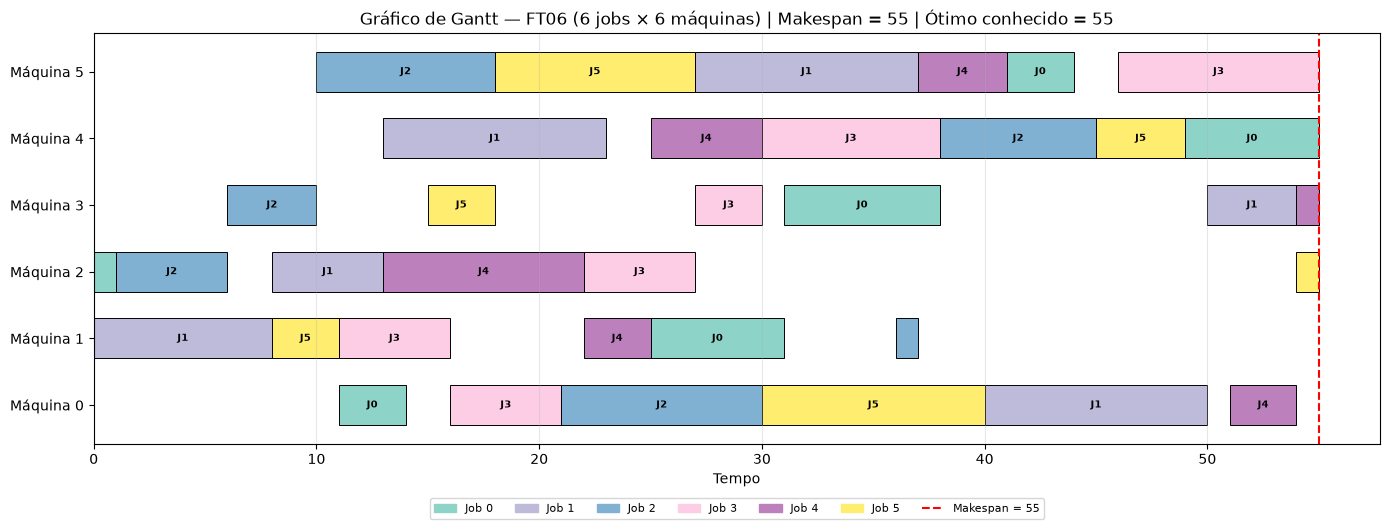

Gráfico salvo como 'gantt_ft06.png'


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

cores = plt.cm.Set3(np.linspace(0, 1, n_jobs))

altura = max(5, n_machines * 0.9)
fig, ax = plt.subplots(figsize=(14, altura))

for (i, j, m, start, p) in schedule:
    ax.barh(
        y=m,           
        width=p,       
        left=start,    
        height=0.6,
        color=cores[i],
        edgecolor='black',
        linewidth=0.7
    )
    if p > makespan * 0.04:
        ax.text(
            start + p / 2, m, f'J{i}',
            ha='center', va='center', fontsize=7, fontweight='bold'
        )

ax.axvline(x=makespan, color='red', linestyle='--', linewidth=1.5)

ax.set_yticks(range(n_machines))
ax.set_yticklabels([f'Máquina {m}' for m in range(n_machines)])
ax.set_xlabel('Tempo')
titulo = f'Gráfico de Gantt — {INSTANCIA.upper()} ({n_jobs} jobs × {n_machines} máquinas) | Makespan = {makespan:.0f}'
if OTIMO_CONHECIDO:
    titulo += f' | Ótimo conhecido = {OTIMO_CONHECIDO}'
ax.set_title(titulo)
ax.grid(axis='x', alpha=0.3)

patches = [mpatches.Patch(color=cores[i], label=f'Job {i}') for i in range(n_jobs)]
patches.append(plt.Line2D([0], [0], color='red', linestyle='--',
                           label=f'Makespan = {makespan:.0f}'))
ncols = min(n_jobs + 1, 8)
ax.legend(handles=patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.12), ncol=ncols, fontsize=8)

plt.tight_layout()
nome_png = f"gantt_{INSTANCIA}.png"
plt.savefig(nome_png, dpi=150, bbox_inches='tight')
plt.show()

---
## Passo 9 — Verificação Formal de Factibilidade

Além da prova de otimalidade fornecida pelo Gurobi (Gap = 0%), verifica **programaticamente** que a solução encontrada respeita todas as restrições do modelo:

1. **Precedência intra-job:** para todo job $i$ e toda operação $j$, confirma que $S_{i,j+1} \geq S_{i,j} + p_{ij}$
2. **Não-sobreposição nas máquinas:** para todo par de operações na mesma máquina, confirma que os intervalos de tempo são disjuntos

Esta verificação é independente do solver — usei apenas os valores das variáveis retornados pelo Gurobi.

In [9]:
ok    = True
erros = []

# VERIFICAÇÃO 1: Precedência intra-job
# Para todo job i e operação j: S[i,j+1] >= S[i,j] + p[i][j]
# Tolerância de 1e-6 para erros numéricos de ponto flutuante

for i, job in enumerate(jobs_data):
    for j in range(len(job) - 1):
        _, p = job[j]
        inicio_j   = S[i, j].X    
        inicio_j1  = S[i, j+1].X  
        termino_j  = inicio_j + p  

        if inicio_j1 < termino_j - 1e-6:
            erros.append(
                f"[ERRO] Precedência violada: Job {i}, Op {j} termina em "
                f"{termino_j:.1f} mas Op {j+1} começa em {inicio_j1:.1f}"
            )
            ok = False

# VERIFICAÇÃO 2: Não-sobreposição nas máquinas
# Para cada par de operações (i,j) e (k,l) na mesma máquina:
# os intervalos [S[i,j], S[i,j]+p_ij) e [S[k,l], S[k,l]+p_kl)

for m, ops in machine_ops.items():
    for a in range(len(ops)):
        for b in range(a + 1, len(ops)):
            i, j = ops[a]
            k, l = ops[b]
            s1, p1 = S[i, j].X, jobs_data[i][j][1] 
            s2, p2 = S[k, l].X, jobs_data[k][l][1]  

            # Dois intervalos [s1, s1+p1) e [s2, s2+p2) são disjuntos se:
            # s1+p1 <= s2  (primeiro termina antes do segundo começar) OU
            # s2+p2 <= s1  (segundo termina antes do primeiro começar)
            sobreposicao = not (s1 + p1 <= s2 + 1e-6 or s2 + p2 <= s1 + 1e-6)
            if sobreposicao:
                erros.append(
                    f"[ERRO] Sobreposição: Máquina {m}, "
                    f"Job {i}/Op {j} [{s1:.0f},{s1+p1:.0f}) e "
                    f"Job {k}/Op {l} [{s2:.0f},{s2+p2:.0f})"
                )
                ok = False


print("VERIFICAÇÃO FORMAL DE FACTIBILIDADE")
print("-" * 50)
if ok:
    print("OK — Todas as restrições de precedência respeitadas")
    print("OK — Nenhuma sobreposição de operações nas máquinas")
    print(f"OK — Makespan = {makespan:.0f}")
    if OTIMO_CONHECIDO:
        if abs(makespan - OTIMO_CONHECIDO) < 1e-3:
            print(f"OK — Solução ÓTIMA confirmada (GAP = 0,00%)")
            print(f"     Makespan = {makespan:.0f} == Ótimo conhecido = {OTIMO_CONHECIDO}")
        else:
            diff = abs(makespan - OTIMO_CONHECIDO) / OTIMO_CONHECIDO * 100
            print(f"     GAP em relação ao ótimo: {diff:.2f}%")
else:
    for e in erros:
        print(e)


print()
print("=" * 57)
print(f"  RESUMO FINAL — {INSTANCIA.upper()}")
print("=" * 57)
print(f"  Instância         : {n_jobs} jobs × {n_machines} máquinas")
print(f"  Formulação        : Disjuntiva MIP (Manne, 1960)")
print(f"  Solver            : Gurobi (API gurobipy)")
print(f"  Makespan obtido   : {makespan:.0f}")
if OTIMO_CONHECIDO:
    print(f"  Ótimo literatura  : {OTIMO_CONHECIDO}")
print(f"  MIP Gap           : {gap:.2f}%")
print(f"  Tempo de solução  : {tempo:.3f}s")
print(f"  Nós B&B           : {int(model.NodeCount)}")
print(f"  Variáveis binárias: {len(x)}")
print(f"  Var. contínuas    : {len(S) + 1}")
print(f"  Restrições        : {model.NumConstrs}")
print("=" * 57)

VERIFICAÇÃO FORMAL DE FACTIBILIDADE
--------------------------------------------------
OK — Todas as restrições de precedência respeitadas
OK — Nenhuma sobreposição de operações nas máquinas
OK — Makespan = 55
OK — Solução ÓTIMA confirmada (GAP = 0,00%)
     Makespan = 55 == Ótimo conhecido = 55

  RESUMO FINAL — FT06
  Instância         : 6 jobs × 6 máquinas
  Formulação        : Disjuntiva MIP (Manne, 1960)
  Solver            : Gurobi (API gurobipy)
  Makespan obtido   : 55
  Ótimo literatura  : 55
  MIP Gap           : 0.00%
  Tempo de solução  : 0.460s
  Nós B&B           : 1
  Variáveis binárias: 90
  Var. contínuas    : 37
  Restrições        : 216



---

## Referências

- **King, B.; Hildebrand, R. (2024).** *Job Shop Scheduling with Integer Programming, Shifting Bottleneck, and Decision Diagrams: A Computational Study.* arXiv:2407.18111. https://arxiv.org/abs/2407.18111

- **Manne, A.S. (1960).** On the Job Shop Scheduling Problem. *Operations Research*, 8(2), 219–223.

- **Fisher, H.; Thompson, G.L. (1963).** Probabilistic Learning Combinations of Local Job-Shop Scheduling Rules. *Industrial Scheduling*, Prentice-Hall.

- **Ku, W.-Y.; Beck, J.C. (2016).** Mixed Integer Programming Models for Job Shop Scheduling: A Computational Analysis. *Computers & Operations Research*, 73, 165–173. https://tidel.mie.utoronto.ca/pubs/JSP_CandOR_2016.pdf

- **Instâncias benchmark:** https://github.com/tamy0612/JSPLIB